# EDA

Raw Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
df = pd.read_csv('aug_train.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/aug_train.csv'

Understand Data

In [ ]:
display(df.head())

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8.0,0.0


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (10236, 14)


In [ ]:
print("Columns:")
print(df.columns.tolist())

Columns:
['enrollee_id', 'city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'target']


In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10236 entries, 0 to 10235
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             10236 non-null  int64  
 1   city                    10236 non-null  object 
 2   city_development_index  10236 non-null  float64
 3   gender                  7878 non-null   object 
 4   relevent_experience     10236 non-null  object 
 5   enrolled_university     10033 non-null  object 
 6   education_level         9992 non-null   object 
 7   major_discipline        8715 non-null   object 
 8   experience              10207 non-null  object 
 9   company_size            7042 non-null   object 
 10  company_type            6967 non-null   object 
 11  last_new_job            10006 non-null  object 
 12  training_hours          10235 non-null  float64
 13  target                  10235 non-null  float64
dtypes: float64(3), in

Statistical Analysis

In [ ]:
print("Statistical Description:")
display(df.describe())

Statistical Description:


,enrollee_id,city_development_index,training_hours,target
count,10236.000000,10236.000000,10235.000000,10235.000000
mean,16902.177608,0.828865,64.922716,0.248461
std,9640.710965,0.122971,58.987239,0.432142
min,2.000000,0.448000,1.000000,0.000000
25%,8632.250000,0.740000,23.000000,0.000000
50%,16917.000000,0.901000,47.000000,0.000000
75%,25284.250000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


Missing Value Check

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
enrollee_id                  0
city                         0
city_development_index       0
gender                    2358
relevent_experience          0
enrolled_university        203
education_level            244
major_discipline          1521
experience                  29
company_size              3194
company_type              3269
last_new_job               230
training_hours               1
target                       1
dtype: int64


Duplicates Check

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


visualization

In [ ]:
print("Target Distribution:")
print(df['target'].value_counts())

Target Distribution:
target
0.0    7692
1.0    2543
Name: count, dtype: int64


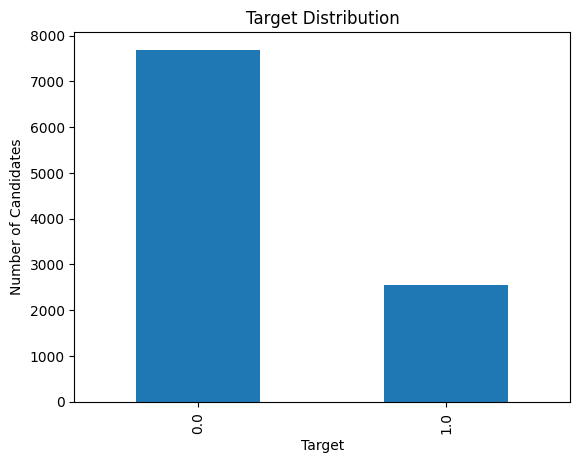

In [ ]:
df['target'].value_counts().plot(kind='bar')

plt.xlabel('Target')
plt.ylabel('Number of Candidates')
plt.title('Target Distribution')
plt.show()

categorical&numberical Analisis

In [ ]:
numeric_features = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = df.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['enrollee_id', 'city_development_index', 'training_hours', 'target']

Categorical Features:
['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']


Visualization

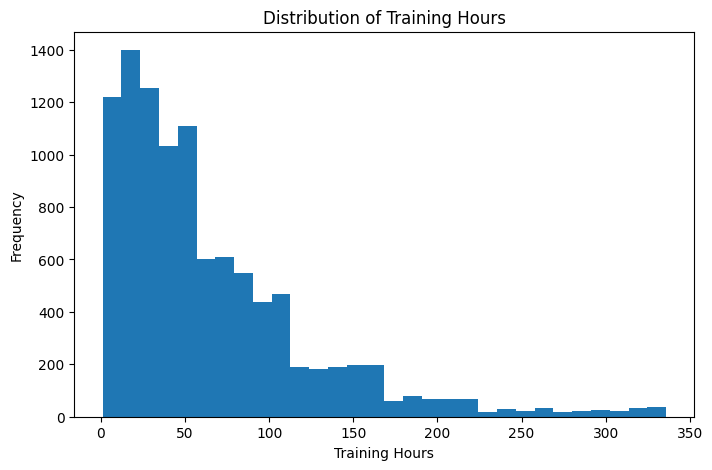

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df['training_hours'].dropna(), bins=30)

plt.xlabel('Training Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Training Hours')

plt.show()

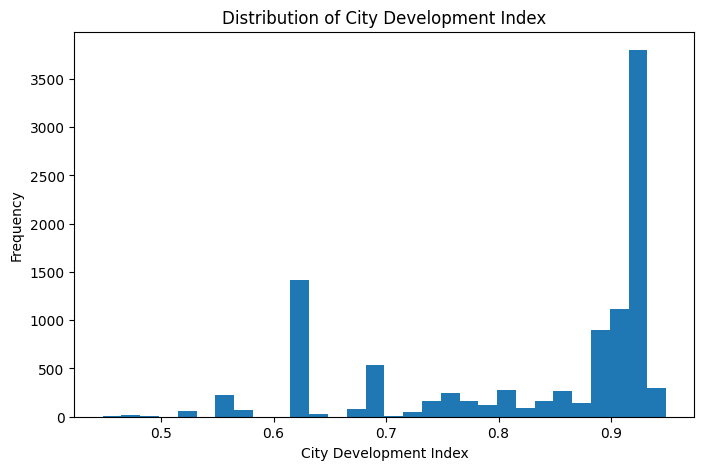

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df['city_development_index'].dropna(), bins=30)

plt.xlabel('City Development Index')
plt.ylabel('Frequency')
plt.title('Distribution of City Development Index')

plt.show()

outliers Detection

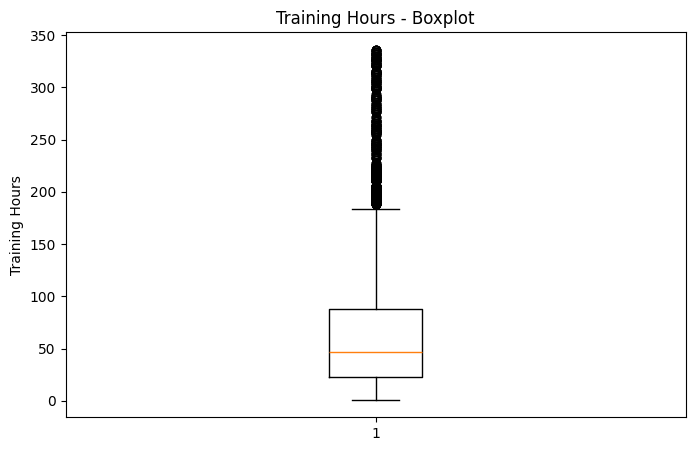

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['training_hours'].dropna())

plt.ylabel('Training Hours')
plt.title('Training Hours - Boxplot')

plt.show()

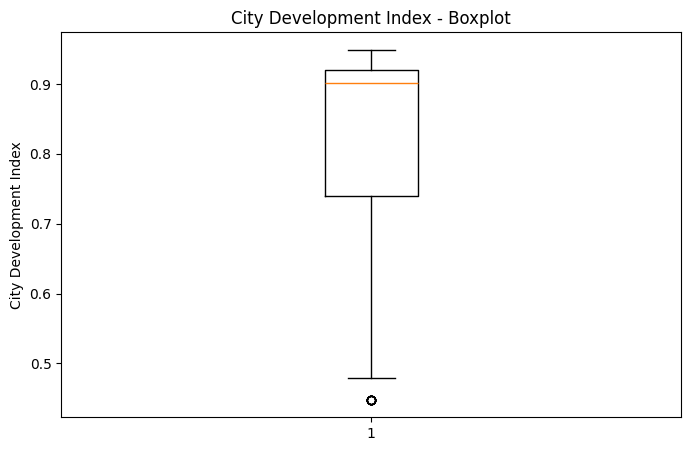

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot(df['city_development_index'].dropna())

plt.ylabel('City Development Index')
plt.title('City Development Index - Boxplot')

plt.show()

Correlation/Relationships

<Figure size 800x500 with 0 Axes>

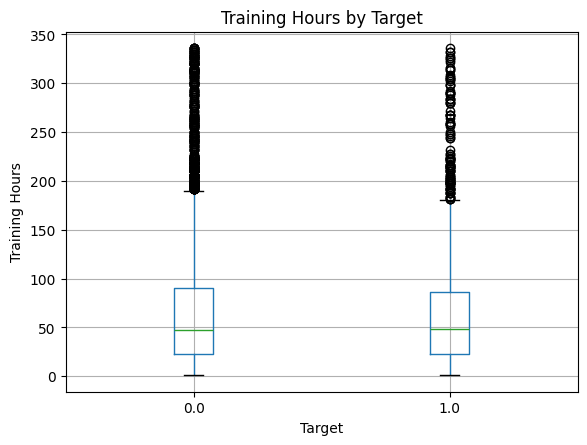

In [ ]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column='training_hours',
    by='target'
)

plt.xlabel('Target')
plt.ylabel('Training Hours')
plt.title('Training Hours by Target')

plt.suptitle('')

plt.show()

<Figure size 800x500 with 0 Axes>

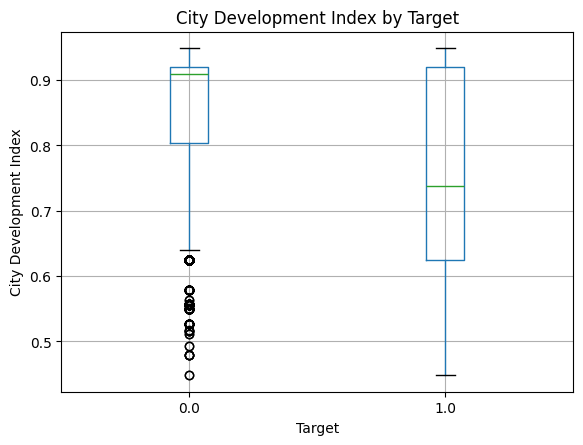

In [ ]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column='city_development_index',
    by='target'
)

plt.xlabel('Target')
plt.ylabel('City Development Index')
plt.title('City Development Index by Target')

plt.suptitle('')

plt.show()

identify proplem

اكتشفت من خلال تحليل البيانات ان ال
 target  غير متوازن
مع وجود بعض
outliers .في بعض . features  ال

# Data preprocessing

libraries

           Encoding Original Data

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
df_encoded = df.copy()

categorical_features = df_encoded.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

encoded_data = encoder.fit_transform(df_encoded[categorical_features])

encoded_columns = encoder.get_feature_names_out(categorical_features)

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoded_columns,
    index=df_encoded.index
)

numeric_df = df_encoded.drop(columns=categorical_features)

df_encoded = pd.concat([numeric_df, encoded_df], axis=1)

display(df_encoded.head())
print("Original shape:", df.shape)
print("Encoded shape:", df_encoded.shape)

,enrollee_id,city_development_index,training_hours,target,city_city_1,city_city_10,city_city_100,city_city_101,city_city_102,city_city_103,...,company_type_Public Sector,company_type_Pvt Ltd,company_type_nan,last_new_job_1,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never,last_new_job_nan
0,8949,0.920,36.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,29725,0.776,47.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,11561,0.624,83.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,33241,0.789,52.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,666,0.767,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Original shape: (10236, 14)
Encoded shape: (10236, 193)


       Scale Original Numerical Data

In [ ]:
from sklearn.preprocessing import StandardScaler

df_scaled = df.copy()

numeric_columns = df_scaled.select_dtypes(include=['int64', 'float64']).columns

scaler_df = StandardScaler()

df_scaled[numeric_columns] = scaler_df.fit_transform(
    df_scaled[numeric_columns]
)

display(df_scaled.head())

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,-0.824998,city_103,0.741144,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,-0.490346,1.739188
1,1.330135,city_40,-0.429923,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,-0.303855,-0.574981
2,-0.554050,city_21,-1.666049,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,0.306476,-0.574981
3,1.694856,city_115,-0.324202,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,-0.219087,1.739188
4,-1.684209,city_162,-0.503114,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,-0.965048,-0.574981


Compare Before and After Scaling

In [ ]:
print("Before Scaling:")
display(df[numeric_columns].head())

print("After Scaling:")
display(df_scaled[numeric_columns].head())

print("\nMean after scaling:")
print(df_scaled[numeric_columns].mean())

print("\nStandard deviation after scaling:")
print(df_scaled[numeric_columns].std())

Before Scaling:


,enrollee_id,city_development_index,training_hours,target
0,8949,0.920,36.0,1.0
1,29725,0.776,47.0,0.0
2,11561,0.624,83.0,0.0
3,33241,0.789,52.0,1.0
4,666,0.767,8.0,0.0


After Scaling:


,enrollee_id,city_development_index,training_hours,target
0,-0.824998,0.741144,-0.490346,1.739188
1,1.330135,-0.429923,-0.303855,-0.574981
2,-0.554050,-1.666049,0.306476,-0.574981
3,1.694856,-0.324202,-0.219087,1.739188
4,-1.684209,-0.503114,-0.965048,-0.574981



Mean after scaling:
enrollee_id              -3.193139e-17
city_development_index   -7.243565e-16
training_hours           -6.803438e-17
target                    6.942284e-17
dtype: float64

Standard deviation after scaling:
enrollee_id               1.000049
city_development_index    1.000049
training_hours            1.000049
target                    1.000049
dtype: float64


        Handle Duplicates

In [ ]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (10236, 14)


        Handle Outliers

In [ ]:
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ].shape[0]

    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    outliers_after = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ].shape[0]

    print(f"{column}")
    print(f"Outliers before handling: {outliers_before}")
    print(f"Outliers after handling: {outliers_after}")
    print("-" * 40)

    return df

In [ ]:
df = handle_outliers(df, 'training_hours')
df = handle_outliers(df, 'city_development_index')

training_hours
Outliers before handling: 488
Outliers after handling: 0
----------------------------------------
city_development_index
Outliers before handling: 9
Outliers after handling: 0
----------------------------------------


        outliers visualization

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

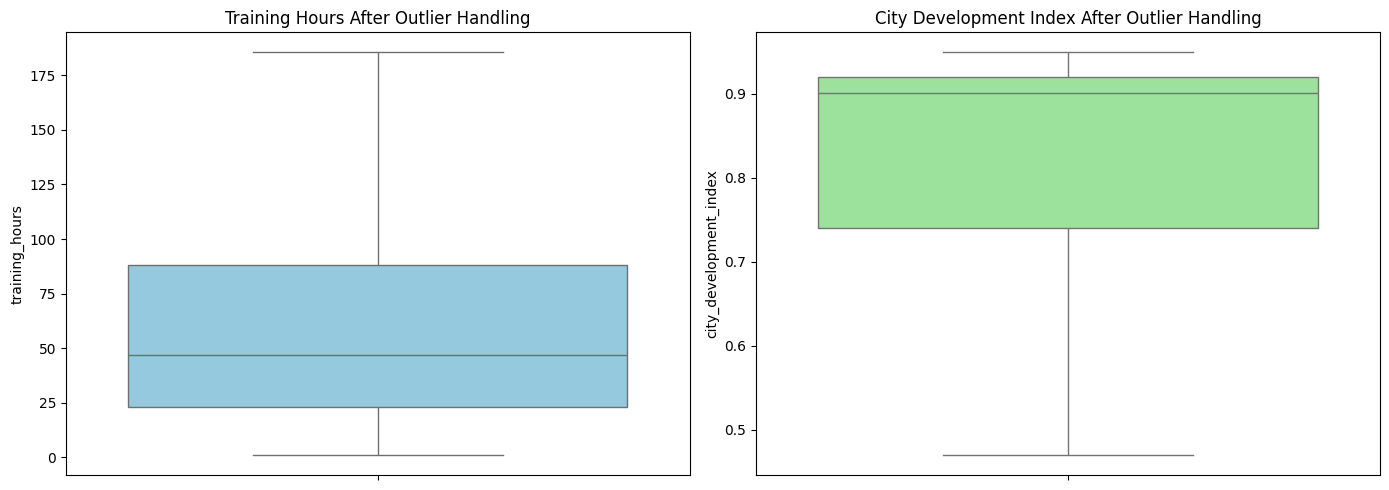

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

sns.boxplot(
    data=df,
    y='training_hours',
    color='skyblue'
)

plt.title('Training Hours After Outlier Handling')

plt.subplot(1, 2, 2)

sns.boxplot(
    data=df,
    y='city_development_index',
    color='lightgreen'
)

plt.title('City Development Index After Outlier Handling')

plt.tight_layout()
plt.show()

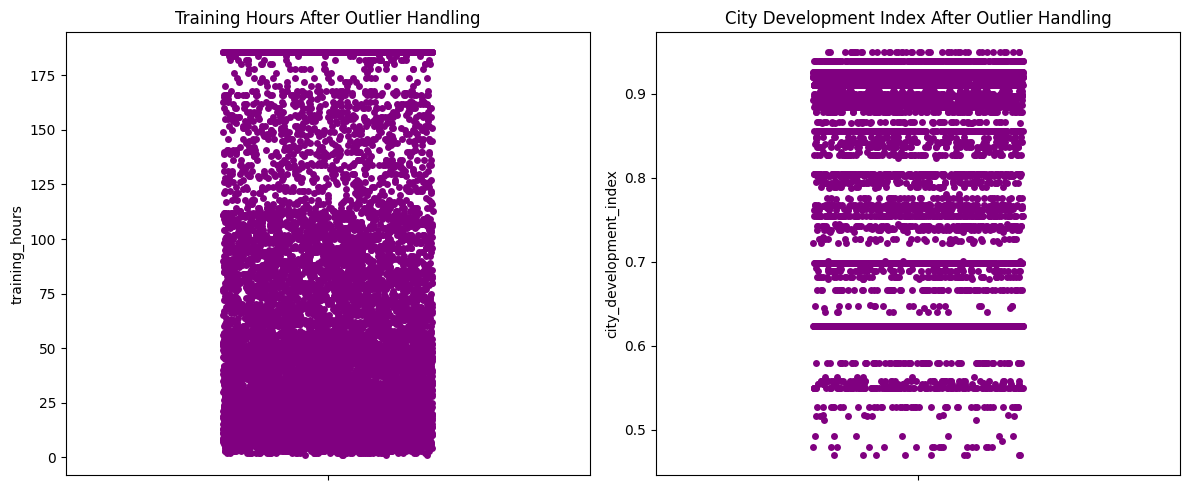

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

sns.stripplot(
    data=df,
    y='training_hours',
    color='purple',
    jitter=0.2,
    size=5
)

plt.title('Training Hours After Outlier Handling')

plt.subplot(1, 2, 2)

sns.stripplot(
    data=df,
    y='city_development_index',
    color='purple',
    jitter=0.2,
    size=5
)

plt.title('City Development Index After Outlier Handling')

plt.tight_layout()
plt.show()

         Feature Engineering / Selection

                    Separate Features and Target

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10236, 13)
Target Shape: (10236,)


                  Remove ID Column

In [ ]:
X = X.drop('enrollee_id', axis=1)

print("Features after removing ID:")
print(X.columns.tolist())

Features after removing ID:
['city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours']


               Feature Engineering

In [ ]:
X['experience_years'] = X['experience'].replace({
    '<1': 0.5,
    '>20': 21
}).astype(float)

X['high_experience'] = (X['experience_years'] >= 5).astype(int)

X['training_per_experience'] = X['training_hours'] / (X['experience_years'] + 1)

X['large_company'] = X['company_size'].isin([
    '1000-4999',
    '5000-9999',
    '10000+'
]).astype(int)

print("Feature Engineering completed successfully!")

print(X[['experience_years', 'high_experience',
         'training_per_experience', 'large_company']].head())

Feature Engineering completed successfully!
   experience_years  high_experience  training_per_experience  large_company
0              21.0                1                 1.636364              0
1              15.0                1                 2.937500              0
2               5.0                1                13.833333              0
3               0.5                0                34.666667              0
4              21.0                1                 0.363636              0


      Train / Test Split

In [ ]:
nan_indices = y[y.isna()].index
X = X.drop(nan_indices)
y = y.drop(nan_indices)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8188, 16)
X_test: (2047, 16)
y_train: (8188,)
y_test: (2047,)


     Identify Numerical & Categorical Features

In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['city_development_index', 'training_hours', 'experience_years', 'high_experience', 'training_per_experience', 'large_company']

Categorical Features:
['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']


         Handle Missing Values

        Transformation-encode-scaling

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

balance

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train, y_train)

print("Before Balancing:")
print(y_train.value_counts())

print("\nAfter Balancing:")
print(y_train_balanced.value_counts())

Before Balancing:
target
0.0    6154
1.0    2034
Name: count, dtype: int64

After Balancing:
target
0.0    6154
1.0    6154
Name: count, dtype: int64


     Apply Full Preprocessing

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train_balanced)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train Shape:", X_train_processed.shape)
print("Processed X_test Shape:", X_test_processed.shape)

Processed X_train Shape: (12308, 183)
Processed X_test Shape: (2047, 183)


    Convert Processed Data to DataFrames

In [ ]:
feature_names = preprocessor.get_feature_names_out()

X_train_processed= pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train_balanced.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)
print("===== Data After Encoding =====")

print(X_train_processed.head())

===== Data After Encoding =====
   num__city_development_index  num__training_hours  num__experience_years  \
0                     0.884638            -0.457845               1.724687   
1                     0.371150            -0.377164               0.076994   
2                     0.780452            -1.062957               1.724687   
3                     0.780452            -1.083127               0.676155   
4                    -1.347922            -0.820912              -0.372376   

   num__high_experience  num__training_per_experience  num__large_company  \
0               0.64171                     -0.587886           -0.478494   
1               0.64171                     -0.433532            2.089890   
2               0.64171                     -0.686410           -0.478494   
3               0.64171                     -0.677433            2.089890   
4               0.64171                     -0.526309           -0.478494   

   cat__city_city_1  cat__city_city_

       Check Missing Values After Processing

In [ ]:
print("Missing values in X_train:",
      X_train_processed.isnull().sum().sum())

print("Missing values in X_test:",
      X_test_processed.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


      final data

In [ ]:
print("===== FINAL DATA =====")

print("X_train:", X_train_processed.shape)
print("X_test:", X_test_processed.shape)
print("y_train:", y_train_balanced.shape)
print("y_test:", y_test.shape)

print("\nData preprocessing completed successfully!")

===== FINAL DATA =====
X_train: (12308, 183)
X_test: (2047, 183)
y_train: (12308,)
y_test: (2047,)

Data preprocessing completed successfully!


        Save Prepared Data

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [ ]:

svm_model = SVC(C=10, kernel='rbf', gamma='scale', random_state=42)
svm_model.fit(X_train_processed, y_train_balanced)

y_pred = svm_model.predict(X_test_processed)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of SVM: {accuracy:.2f}")

conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy of SVM: 0.73
Confusion Matrix:
 [[1206  332]
 [ 211  298]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.78      0.82      1538
         1.0       0.47      0.59      0.52       509

    accuracy                           0.73      2047
   macro avg       0.66      0.68      0.67      2047
weighted avg       0.76      0.73      0.74      2047



In [ ]:
feature_names = ['num__training_hours', 'num__city_development_index']

if hasattr(X_train_processed, 'loc'):
    X_train_2d = X_train_processed[feature_names].values
else:

    X_train_2d = X_train_processed[:, :2]
    feature_names = ['Feature 1', 'Feature 2']

In [ ]:
svm_2d = SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced', random_state=42)
svm_2d.fit(X_train_2d, y_train_balanced)

SVC(C=10, class_weight='balanced', random_state=42)

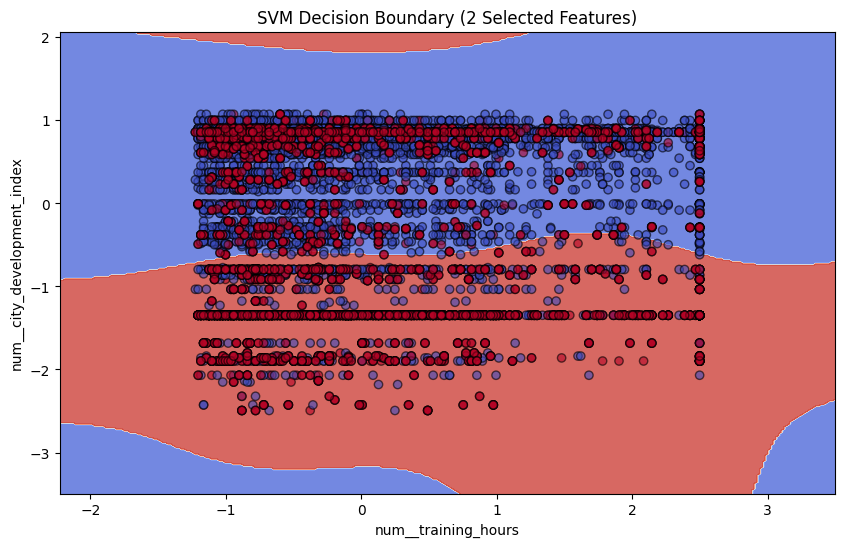

In [ ]:
h = .02
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train_balanced,
    cmap=plt.cm.coolwarm,
    edgecolors='k',
    alpha=0.6
)

plt.title('SVM Decision Boundary (2 Selected Features)')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
if hasattr(X_test_processed, 'iloc'):
    X_test_2d = X_test_processed.iloc[:, :2].values
else:
    X_test_2d = X_test_processed[:, :2]

In [ ]:
y_pred_2d = svm_2d.predict(X_test_2d)

print("=== Evaluation for 2D SVM Model ===")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_2d))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_2d))

=== Evaluation for 2D SVM Model ===

Confusion Matrix:
[[897 641]
 [315 194]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.58      0.65      1538
         1.0       0.23      0.38      0.29       509

    accuracy                           0.53      2047
   macro avg       0.49      0.48      0.47      2047
weighted avg       0.61      0.53      0.56      2047



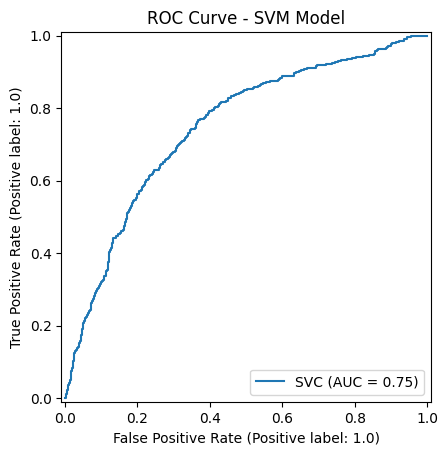

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(svm_model, X_test_processed, y_test)
plt.title('ROC Curve - SVM Model')
plt.show()

In [ ]:
import joblib
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

print("تم الحفظ بنجاح!")

تم الحفظ بنجاح!


In [ ]:
import joblib

target_path = r"c:\Users\Marioma\Documents\Smart-Recruitment-Assistant-main\Smart-Recruitment-Assistant-main\Graduation project-Team5\Graduation project-Team5"

joblib.dump(preprocessor, f"{target_path}\\preprocessor.pkl")
joblib.dump(svm_model, f"{target_path}\\svm_model.pkl")

print("تم إعادة حفظ الملفين بنجاح بنفس إصدار البيئة الحالية!")

تم إعادة حفظ الملفين بنجاح بنفس إصدار البيئة الحالية!
